In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle


path = "../data/headless_bugtrap_mppi/bugtrap_seed_1.pkl"

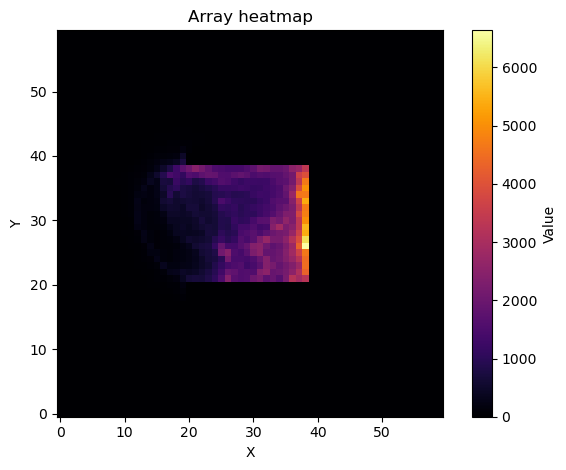

In [2]:
# --- Load ---
# If gzipped:
# import gzip
# with gzip.open(path, "rb") as f:
#     obj = pickle.load(f)

with open(path, "rb") as f:
    obj = pickle.load(f)

# If the pickle stores the array directly:
arr = np.asarray(obj).T

# If it stored a dict, pick the right key:
# arr = np.asarray(obj["my_array"])

# (Optional) If your data has extra leading dims (e.g., 1,32,20,60,60)
# and you want a single 60x60 heatmap, sum all but the last two:
if arr.ndim > 2:
    arr = arr.sum(axis=tuple(range(arr.ndim - 2)))

# --- Plot heatmap ---
plt.imshow(arr, origin="lower", cmap="inferno", interpolation="nearest")
plt.colorbar(label="Value")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Array heatmap")
plt.tight_layout()
plt.show()

# (Optional) Save figure:
# plt.savefig("heatmap.png", dpi=200)

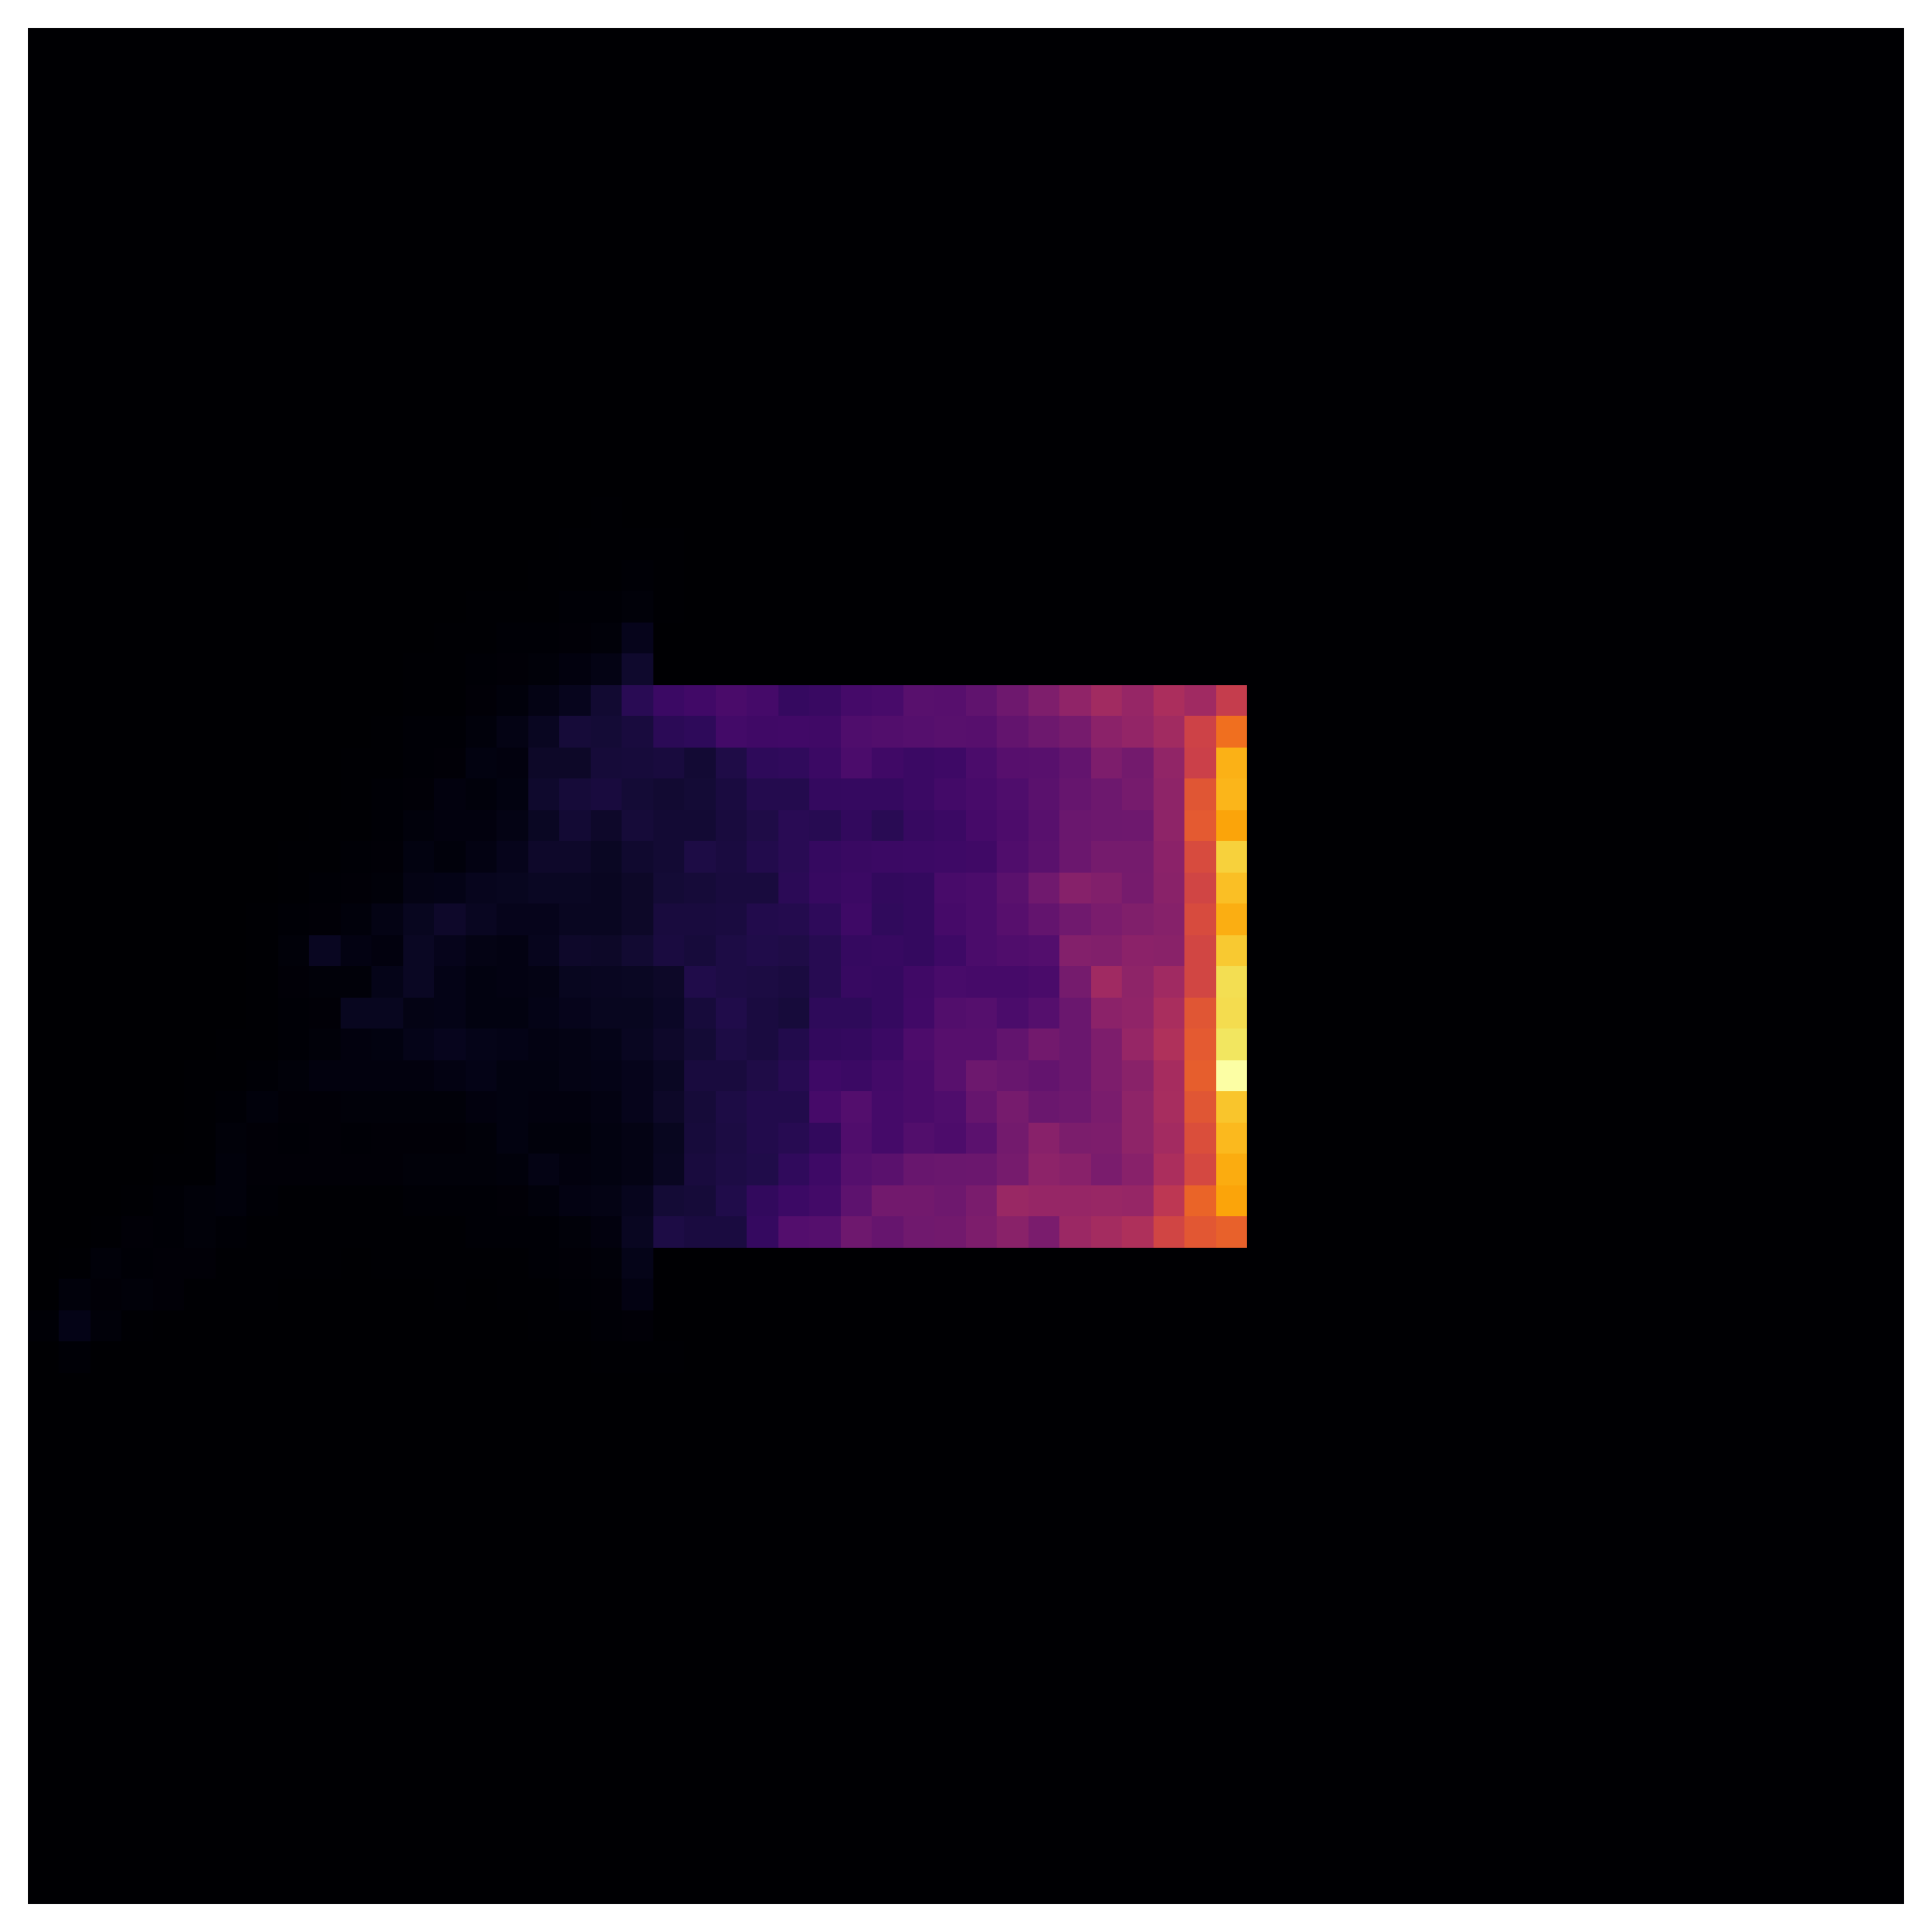

In [3]:

# --- Accumulate arrays from multiple seeds ---
arr_sum = None

for i in range(1,4):
    path = f"../data/headless_bugtrap_mppi/bugtrap_seed_{i}.pkl"
    with open(path, "rb") as f:
        obj = pickle.load(f)

    arr = np.asarray(obj).T

    if arr.ndim > 2:
        arr = arr.sum(axis=tuple(range(arr.ndim - 2)))

    if arr_sum is None:
        arr_sum = arr.copy()
    else:
        arr_sum += arr   # accumulate

# Normalize to [0,1] for qualitative heatmap
arr_norm = (arr_sum - arr_sum.min()) / (arr_sum.max() - arr_sum.min())

# --- Create figure ---
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# Heatmap (qualitative, no axis values)
im = ax.imshow(
    arr_norm,
    origin="lower",
    cmap="inferno",
    interpolation="none"
)

# Remove ticks, labels, spines (clean look)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)


# Tight layout
plt.tight_layout()

# Save high-quality
plt.savefig("heatmap_fancy_trapped.png", dpi=600, bbox_inches="tight")

plt.show()

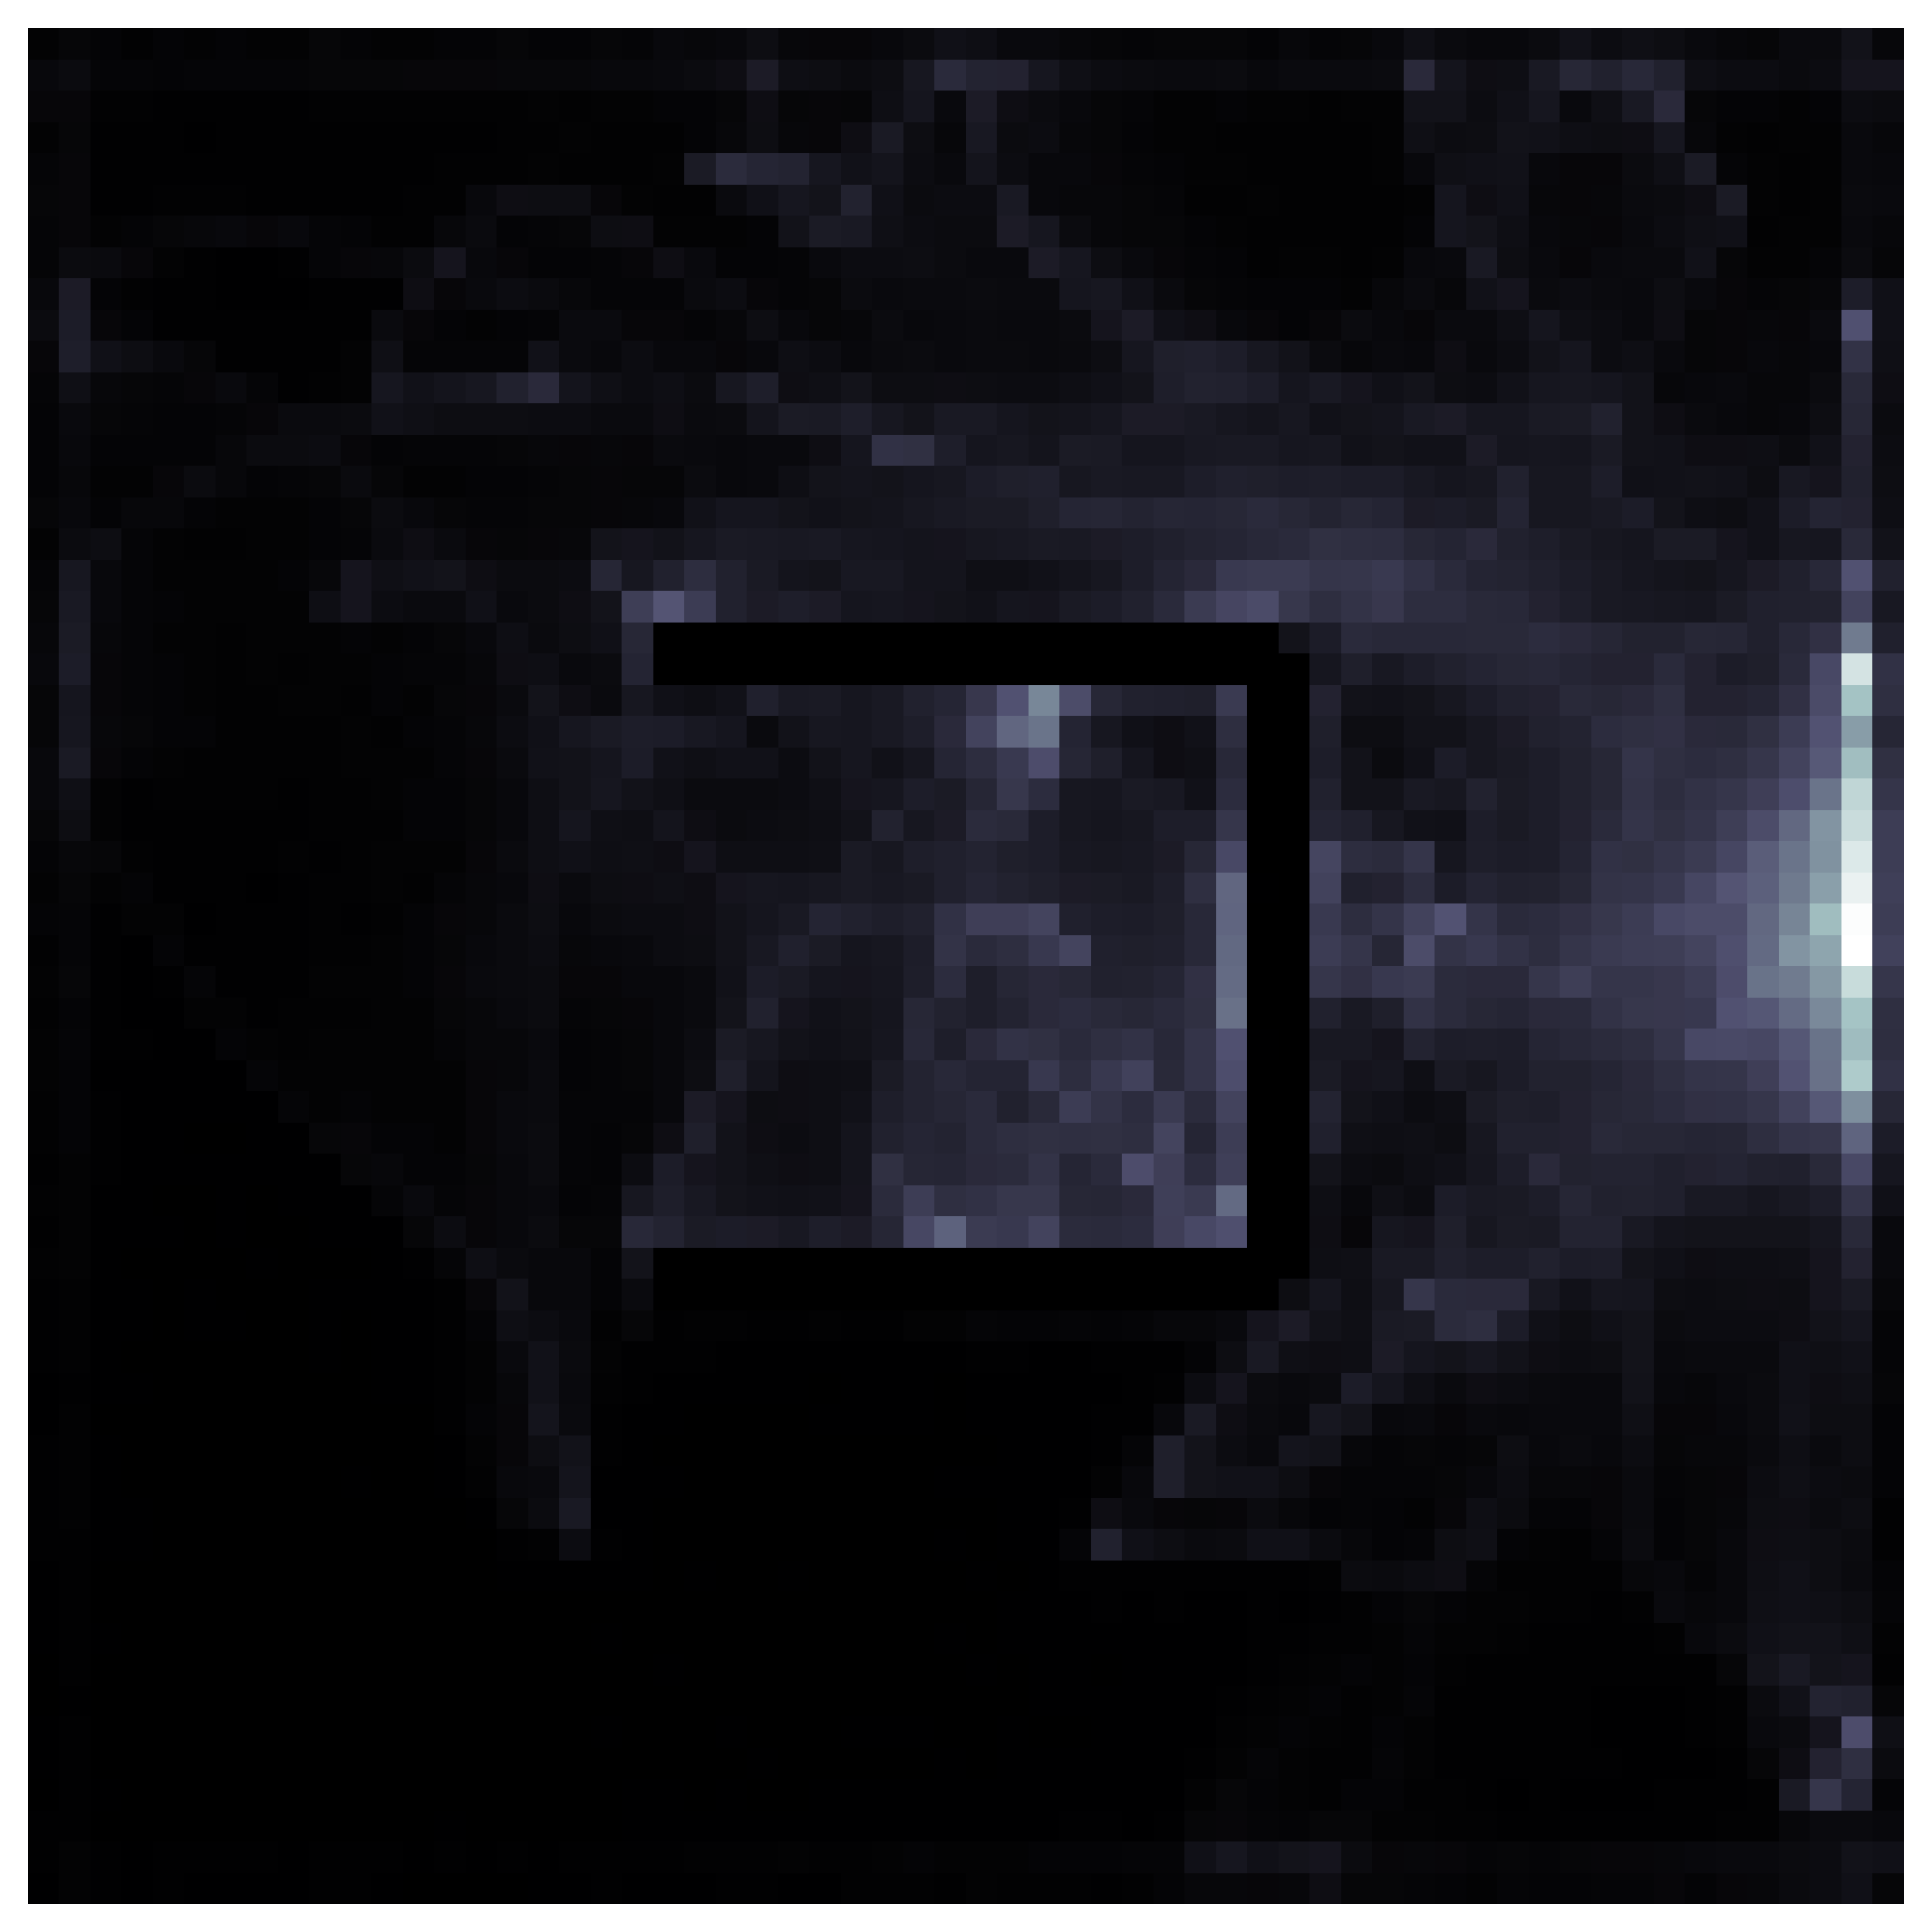

In [7]:
# --- Accumulate arrays from multiple seeds ---
arr_sum = None

for i in range(1,4):
    path = f"../data/headless_bugtrap_mtp/bugtrap_seed_{i}.pkl"
    with open(path, "rb") as f:
        obj = pickle.load(f)

    arr = np.asarray(obj).T

    if arr.ndim > 2:
        arr = arr.sum(axis=tuple(range(arr.ndim - 2)))

    if arr_sum is None:
        arr_sum = arr.copy()
    else:
        arr_sum += arr   # accumulate

# Normalize to [0,1] for qualitative heatmap
arr_norm = (arr_sum - arr_sum.min()) / (arr_sum.max() - arr_sum.min())

# --- Create figure ---
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# Heatmap (qualitative, no axis values)
im = ax.imshow(
    arr_norm,
    origin="lower",
    cmap="bone",
    interpolation="none"
)

# Remove ticks, labels, spines (clean look)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)


# Tight layout
plt.tight_layout()

# Save high-quality
# plt.savefig("heatmap_fancy_escape.png", dpi=600, bbox_inches="tight")

plt.show()
